In [1]:
from pathlib import Path

from jax import config
import jax.numpy as np
config.update("jax_enable_x64", True)

from gwfast.lensing_utils import \
    compute_exact_lensed_angles, \
    compute_exact_lensed_angles_SourceFrame, \
    get_lensed_parameter_sets

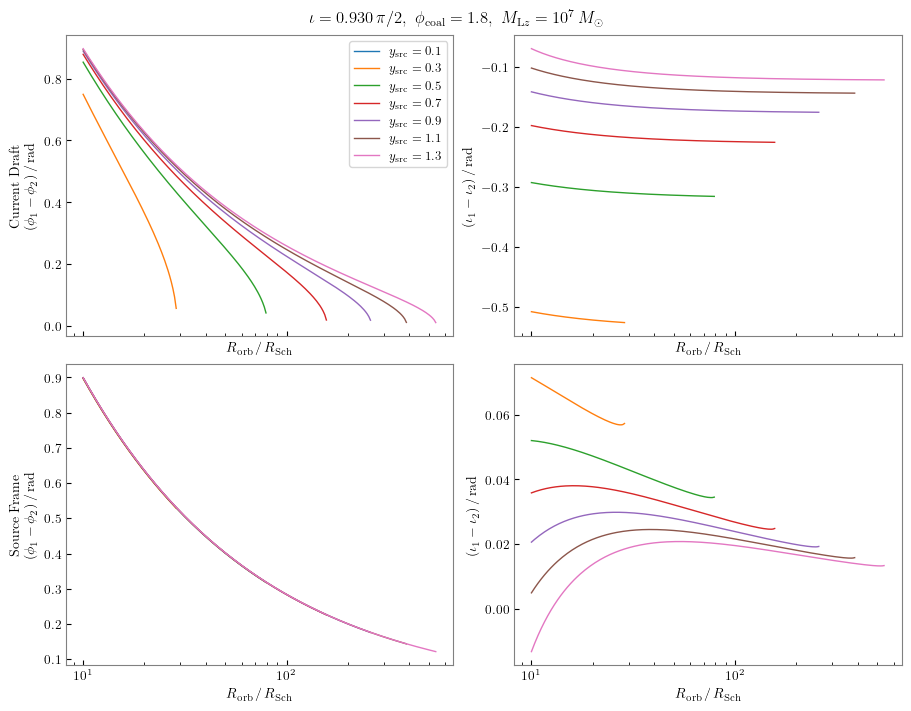

In [5]:
size = 500
iota_frac = 0.93
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, iota_frac * np.pi / 2),
    'Phicoal': np.full(size, 0.8),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}
lensing_params['psi'] = np.full(size, 0.0)
lensing_params['Mc'] = np.full(size, 1.0)

def regulate_phi_diff(phi_diff):
    mod2pi = np.mod(phi_diff, 2*np.pi)
    return np.where(mod2pi > np.pi, mod2pi - 2 * np.pi, mod2pi)

fig, Axes = plt.subplots(2, 2, figsize=(9, 7), 
                         sharex=True, constrained_layout=True)

axes = Axes.flatten()

for idx, y_src in enumerate(range(1, 14, 2)):
    lensing_params['src_pos'] = np.full(size, y_src*0.1)
    lensed_params = compute_exact_lensed_angles(lensing_params)
    
    axes[0].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
                 c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src*0.1:>.1f}$')
    axes[1].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}')

    lensed_params = compute_exact_lensed_angles_SourceFrame(lensing_params)
    
    axes[2].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
                 c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src*0.1:>.1f}$')
    axes[3].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}')
    
axes[0].legend()
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')

# axes[1].set_ylim(-0.5e-15, 2e-15)
axes[0].set_ylabel("Current Draft\n" + r'$(\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[1].set_ylabel(r'$(\iota_1 - \iota_2)\,/\,{\rm rad}$')
axes[2].set_ylabel("Source Frame\n" + r'$(\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[3].set_ylabel(r'$(\iota_1 - \iota_2)\,/\,{\rm rad}$')
fig.suptitle(fr'$\iota = {iota_frac:.3f}\,\pi/2,\ \phi_{{\rm coal}} = 1.8,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
fig.savefig('opening_angle_plot.png', dpi=300)

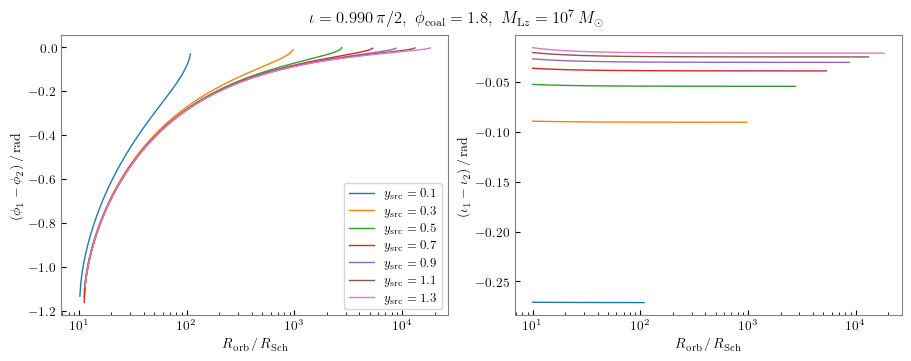

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), 
                         sharex=True, constrained_layout=True)
    
for idx, y_src in enumerate(range(1, 14, 2)):
    lensing_params['src_pos'] = np.full(size, y_src*0.1)
    # lensed_params = compute_exact_lensed_angles(lensing_params)

    approx_lensed = get_lensed_parameter_sets(lensing_params)
    d_iota = approx_lensed[0]['iota'] - approx_lensed[1]['iota'] 
    d_phi = approx_lensed[0]['Phicoal'] - approx_lensed[1]['Phicoal'] 
    
    axes[0].plot(r_orbits, regulate_phi_diff(d_phi), c=f'C{idx}', 
                 label=fr'$y_{{\rm src}} = {y_src*0.1:>.1f}$')
    axes[1].plot(r_orbits, d_iota, c=f'C{idx}')
    
axes[0].legend()
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')
    
axes[0].set_ylabel(r'$(\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[1].set_ylabel(r'$(\iota_1 - \iota_2)\,/\,{\rm rad}$')
fig.suptitle(fr'$\iota = {iota_frac:.3f}\,\pi/2,\ \phi_{{\rm coal}} = 1.8,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
fig.savefig('opening_angle_approx_plot.png', dpi=300)

In [4]:
# fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), 
#                          sharex=True, constrained_layout=True)

size = 400
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, np.pi/2 * 0.99),
    'Phicoal': np.full(size, 1.8),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}

lensed_params = compute_exact_lensed_angles(lensing_params)

In [5]:
lensed_params

{'iota_p': Array([1.54658689, 1.54649213, 1.54639968, 1.54630949, 1.54622148,
        1.54613561, 1.54605182, 1.54597005, 1.54589024, 1.54581236,
        1.54573634, 1.54566214, 1.54558971, 1.54551901, 1.54544999,
        1.54538261, 1.54531684, 1.54525262, 1.54518992, 1.5451287 ,
        1.54506893, 1.54501056, 1.54495357, 1.54489793, 1.54484359,
        1.54479052, 1.5447387 , 1.54468809, 1.54463867, 1.54459041,
        1.54454327, 1.54449723, 1.54445227, 1.54440836, 1.54436547,
        1.54432358, 1.54428266, 1.5442427 , 1.54420366, 1.54416553,
        1.54412829, 1.54409191, 1.54405637, 1.54402166, 1.54398775,
        1.54395463, 1.54392227, 1.54389066, 1.54385979, 1.54382963,
        1.54380016, 1.54377138, 1.54374326, 1.54371579, 1.54368895,
        1.54366273, 1.54363712, 1.5436121 , 1.54358765, 1.54356377,
        1.54354044, 1.54351764, 1.54349537, 1.54347362, 1.54345236,
        1.54343159, 1.5434113 , 1.54339148, 1.54337211, 1.54335319,
        1.5433347 , 1.54331664, 1.5432

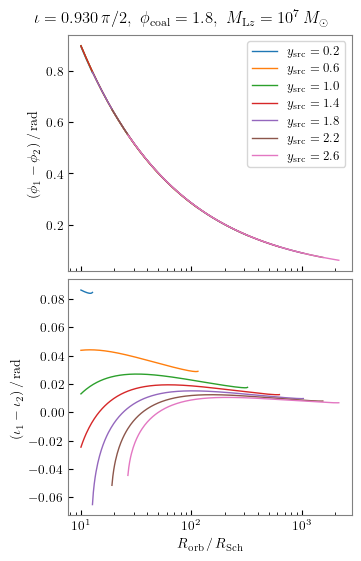

In [15]:
size = 500
iota_frac = 0.93
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, iota_frac * np.pi / 2),
    'Phicoal': np.full(size, 0.8),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}
lensing_params['psi'] = np.full(size, 0.0)
lensing_params['Mc'] = np.full(size, 1.0)

def regulate_phi_diff(phi_diff):
    mod2pi = np.mod(phi_diff, 2*np.pi)
    return np.where(mod2pi > np.pi, mod2pi - 2 * np.pi, mod2pi)

tilde_dls = r_orbits - 2
approx = np.arctan(
    np.sqrt(2 / tilde_dls) * 2 / (1 - 2 / tilde_dls))

fig, Axes = plt.subplots(2, 1, figsize=(3.5, 5.5), 
                         sharex=True, constrained_layout=True)

axes = Axes.flatten()

for idx, y_src in enumerate(range(1, 14, 2)):
    lensing_params['src_pos'] = np.full(size, y_src*0.2)

    lensed_params = compute_exact_lensed_angles_SourceFrame(lensing_params)
    
    axes[0].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
                 c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src*0.2:>.1f}$')
    axes[1].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}')
    
axes[0].legend()
for ax in axes:
    ax.set_xscale('log')
axes[1].set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')

# axes[1].set_ylim(-0.5e-15, 2e-15)
axes[0].set_ylabel(r'$(\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[1].set_ylabel(r'$(\iota_1 - \iota_2)\,/\,{\rm rad}$')
fig.suptitle(fr'$\iota = {iota_frac:.3f}\,\pi/2,\ \phi_{{\rm coal}} = 1.8,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
fig.savefig('updated_opening_angle_plot.png', dpi=300)

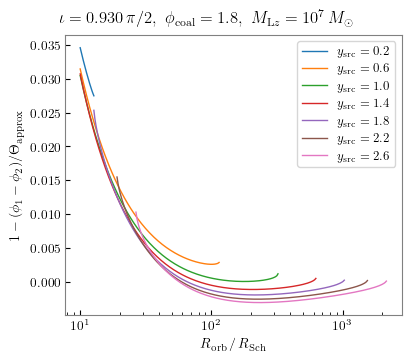

In [14]:
size = 500
iota_frac = 0.93
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, iota_frac * np.pi / 2),
    'Phicoal': np.full(size, 0.8),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}
lensing_params['psi'] = np.full(size, 0.0)
lensing_params['Mc'] = np.full(size, 1.0)

def regulate_phi_diff(phi_diff):
    mod2pi = np.mod(phi_diff, 2*np.pi)
    return np.where(mod2pi > np.pi, mod2pi - 2 * np.pi, mod2pi)

tilde_dls = r_orbits - 2
approx = np.arctan(
    np.sqrt(2 / tilde_dls) * 2 / (1 - 2 / tilde_dls))

fig, ax = plt.subplots(1, 1, figsize=(4, 3.5), 
                         sharex=True, constrained_layout=True)

for idx, y_src in enumerate(range(1, 14, 2)):
    lensing_params['src_pos'] = np.full(size, y_src*0.2)

    lensed_params = compute_exact_lensed_angles_SourceFrame(lensing_params)
    
    ax.plot(r_orbits, 1 - regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']) / approx,
                 c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src*0.2:>.1f}$')
    
ax.legend()

ax.set_xscale('log')
ax.set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')

# axes[1].set_ylim(-0.5e-15, 2e-15)
ax.set_ylabel(r'$1 - (\phi_1 - \phi_2) / \Theta_{\rm approx}$')
fig.suptitle(fr'$\iota = {iota_frac:.3f}\,\pi/2,\ \phi_{{\rm coal}} = 1.8,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
fig.savefig('updated_opening_angle_ratio.png', dpi=300)